In [12]:
# Impor library
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json

In [13]:
# Muat dan pra-pemrosesan dataset CIFAR-10
# CIFAR-10 memiliki 60.000 gambar (32x32 piksel) dalam 10 kelas: 
# airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
print("🔍 Memuat dataset CIFAR-10...")
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalisasi nilai piksel ke rentang [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Encode label ke one-hot (untuk klasifikasi kategorikal)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

🔍 Memuat dataset CIFAR-10...


In [14]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'          
)
datagen.fit(x_train)

In [15]:
# Bangun arsitektur CNN
print("🏗️  Membangun model CNN...")
model = models.Sequential([
    # Layer 1: Conv2D + MaxPooling
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Layer 2: Conv2D + MaxPooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Layer 3: Conv2D + MaxPooling
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Layer 4: Flatten + Dense
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),  # Mencegah overfitting
    layers.Dense(10, activation='softmax')  # 10 kelas output
])

# Tampilkan struktur model
print(model.summary())

🏗️  Membangun model CNN...


/run/media/alannuarii/b25e065d-58a6-4c72-8784-0ed758d4cf00/home/alannuarii/Coding/Python/streamlit_cnn_cifar10/env/lib64/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
# Kompilasi model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [17]:
# Latih model
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2034 - loss: 2.1101

2025-10-18 18:19:49.950770: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 122880000 exceeds 10% of free system memory.


782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - accuracy: 0.2529 - loss: 1.9881 - val_accuracy: 0.3835 - val_loss: 1.6819 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.3481 - loss: 1.7587 - val_accuracy: 0.4429 - val_loss: 1.5147 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.3925 - loss: 1.6552 - val_accuracy: 0.5015 - val_loss: 1.3772 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4276 - loss: 1.5770 - val_accuracy: 0.4908 - val_loss: 1.3674 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4481 - loss: 1.5257 - val_accuracy: 0.5443 - val_loss: 1.2489 - learning_rate: 0.0010
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4740 - loss: 1.4791 - val_accuracy: 0.5682 - val_loss: 1.2066 - learning_rate: 0.0010
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.4857 - loss: 1.4421

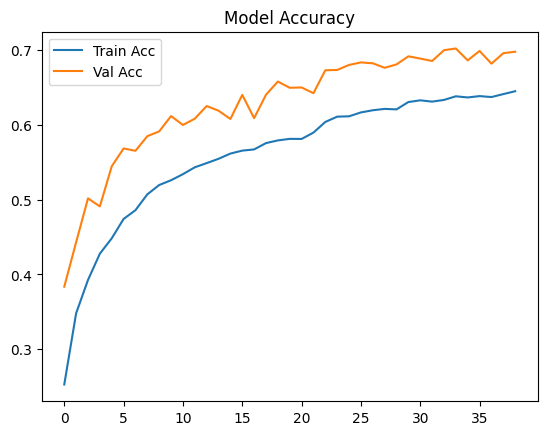

In [18]:
# Visualisasi akurasi dan loss selama pelatihan
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()
plt.close()

In [19]:
# Simpan model
model.save('result/cifar10_cnn.keras')

In [20]:
# Ambil metrik dari objek history
training_metrics = {
    'accuracy': history.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'],
    'loss': history.history['loss'],
    'val_loss': history.history['val_loss']
}

# Simpan ke file JSON
with open('metric/training_metrics.json', 'w') as f:
    json.dump(training_metrics, f)

# Simpan ke file CSV untuk analisis lebih lanjut
df_history = pd.DataFrame(history.history)
df_history.to_csv('metric/training_history.csv', index=False)